## Outgoing

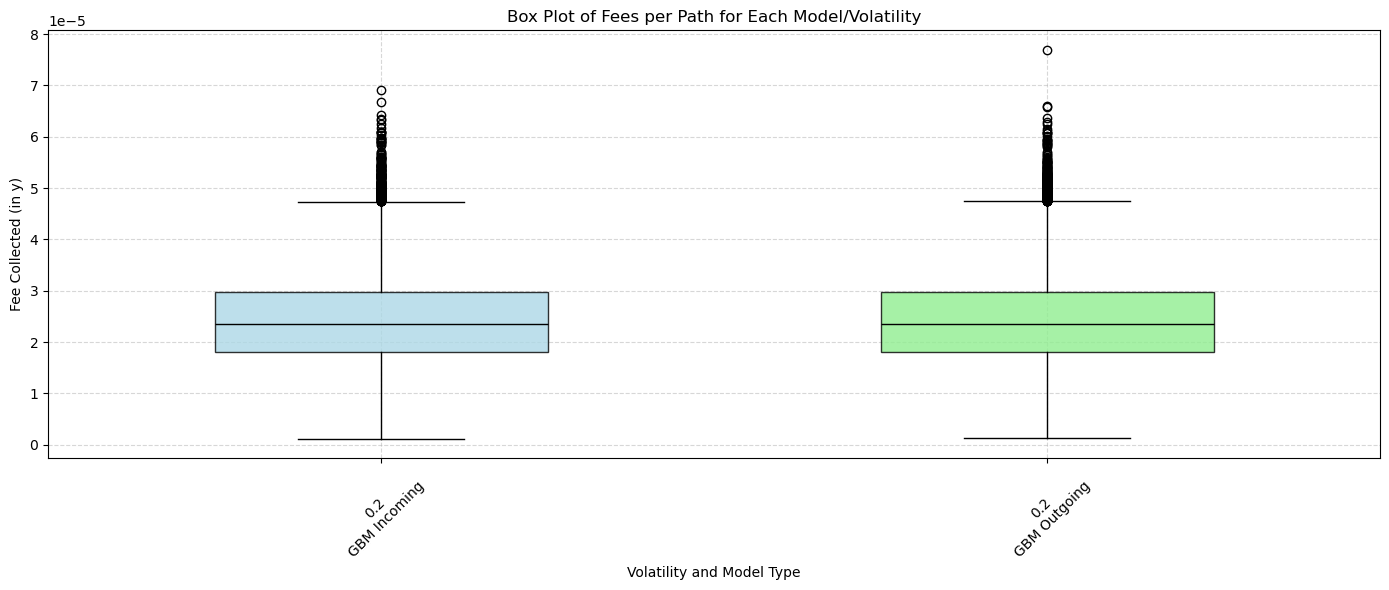

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
n_paths = 30000
n_steps = 2000
dt = 1 / (365 * 24)  # 1-hour timestep
mu = 0
S0 = 1.0
PV0 = 200.0
gamma = 0.003
weights = [0.5]
volatility_range = [0.2]
models = ['GBM']
modes = ['Incoming', 'Outgoing']
fee_dict = {}

# --- Simulation ---
def simulate_fees(model, mode, sigma_annual):
    sigma = sigma_annual / np.sqrt(365 * 24)
    dW = np.random.randn(n_paths, n_steps) * np.sqrt(dt)

    if model == 'OU':
        W = np.cumsum(dW, axis=1)
        theta = 1.0
        mean = 1.0
        S = np.zeros_like(W)
        S[:, 0] = S0
        for i in range(1, n_steps):
            S[:, i] = S[:, i-1] + theta * (mean - S[:, i-1]) * dt + sigma * dW[:, i]
    else:
        W = np.cumsum(dW, axis=1)
        t = np.linspace(dt, n_steps * dt, n_steps)
        S = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)

    w = 0.5
    x0 = w * PV0
    y0 = (1 - w) * PV0
    L = x0**w * y0**(1 - w)

    xt = np.full(n_paths, x0)
    yt = np.full(n_paths, y0)
    fee_y = np.zeros(n_paths)
    fee_y_equiv_from_x = np.zeros(n_paths)

    for i in range(n_steps):
        P_ext = S[:, i]
        P_AMM = (w / (1 - w)) * (yt / xt)
        bid = P_AMM * (1 - gamma)
        ask = P_AMM / (1 - gamma)

        up_mask = P_ext > ask
        down_mask = P_ext < bid

        if mode == 'Incoming':
            if np.any(up_mask):
                denom = (((1 - w)*(1 - gamma))/ w) * P_ext[up_mask]
                x_new = L * denom ** (w - 1)
                delta_x = xt[up_mask] - x_new
                xt[up_mask] -= np.maximum(delta_x, 0)

                y_new = L * denom ** w
                delta_y = (y_new - yt[up_mask]) / (1 - gamma)
                fee_y[up_mask] += gamma * np.maximum(delta_y, 0)
                yt[up_mask] += np.maximum(delta_y, 0)

            if np.any(down_mask):
                denom = ((1 - w) / w) * P_ext[down_mask] / (1 - gamma)
                y_new = L * denom ** w
                delta_y = yt[down_mask] - y_new
                yt[down_mask] -= np.maximum(delta_y, 0)

                x_new = L * denom ** (w - 1)
                delta_x = (x_new - xt[down_mask]) / (1 - gamma)
                fee_x = gamma * np.maximum(delta_x, 0)
                fee_y_equiv_from_x[down_mask] += fee_x * P_ext[down_mask]
                xt[down_mask] += np.maximum(delta_x, 0)

        else:  # Outgoing
            if np.any(up_mask):
                denom = (((1 - w)*(1 - gamma))/w) * P_ext[up_mask]
                x_new = L * denom ** (w - 1)
                delta_x = (xt[up_mask] - x_new) * (1 - gamma)
                xt[up_mask] = x_new
                fee_y_equiv_from_x[up_mask] += (gamma/(1-gamma)) * np.maximum(delta_x, 0) * P_ext[up_mask]
                yt[up_mask] = L * denom ** w

            if np.any(down_mask):
                denom = ((1 - w) / w) * P_ext[down_mask] / (1 - gamma)
                y_new = L * denom ** w
                yt[down_mask] = y_new
                fee_y[down_mask] += gamma * np.maximum((yt[down_mask] - y_new), 0)
                xt[down_mask]= L * denom ** (w - 1)

    return fee_y + fee_y_equiv_from_x

# --- Run and Store Fees in Dictionary ---
for sigma in volatility_range:
    for model in models:
        for mode in modes:
            key = (sigma, model, mode)
            fee_dict[key] = simulate_fees(model, mode, sigma)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(14, 6))
positions = []
labels = []
box_data = []
colors = ['lightblue', 'lightgreen', 'salmon', 'plum']
width = 0.6
count = 1

for sigma in volatility_range:
    for model in models:
        for i, mode in enumerate(modes):
            key = (sigma, model, mode)
            positions.append(count)
            box_data.append(fee_dict[key])
            labels.append(f"{sigma}\n{model} {mode}")
            ax.boxplot(fee_dict[key], positions=[count], widths=0.5,
                       patch_artist=True,
                       boxprops=dict(facecolor=colors[i + 2*(model=='OU')], alpha=0.8),
                       medianprops=dict(color='black'))
            count += 1

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45)
ax.set_ylabel("Fee Collected (in y)")
ax.set_xlabel("Volatility and Model Type")
ax.set_title("Box Plot of Fees per Path for Each Model/Volatility")
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
n_paths = 1
n_steps = 100
dt = 1/(365*24)  # 1-hour timestep
mu = 0
S0 = 1.0
PV0 = 100000
gamma = 0.0003
weights = [0.5]
volatility_range = [0.2]
models = ['GBM']
modes = ['Incoming', 'Outgoing']
fee_dict = {}

# --- Simulation ---
def simulate_fees(model, sigma_annual):
    sigma = sigma_annual / np.sqrt(365 * 24)
    dW = np.random.randn(n_paths, n_steps) * np.sqrt(dt)

    if model == 'OU':
        W = np.cumsum(dW, axis=1)
        theta = 1.0
        mean = 1.0
        S = np.zeros_like(W)
        S[:, 0] = S0
        for i in range(1, n_steps):
            S[:, i] = S[:, i-1] + theta * (mean - S[:, i-1]) * dt + sigma * dW[:, i]
    else:
        W = np.cumsum(dW, axis=1)
        t = np.linspace(dt, n_steps * dt, n_steps)
        S = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)

    w = 0.5
    x0 = w * PV0
    y0 = (1 - w) * PV0
    L = x0**w * y0**(1 - w)
    print(f"x0: {x0}, y0: {y0}, L: {L}")

    xt = np.full(n_paths, x0)
    yt = np.full(n_paths, y0)
    in_fee_y = np.zeros(n_paths)
    in_fee_y_equiv_from_x = np.zeros(n_paths)
    out_fee_y = np.zeros(n_paths)
    out_fee_y_equiv_from_x = np.zeros(n_paths)

    for i in range(n_steps):
        P_ext = S[:, i]
        P_AMM = (w / (1 - w)) * (yt / xt)
        bid = P_AMM * (1 - gamma)
        ask = P_AMM / (1 - gamma)

        up_mask = P_ext > ask
        down_mask = P_ext < bid


        if np.any(up_mask):
            denom = (((1 - w)*(1 - gamma))/ w) * P_ext[up_mask]
            x_new = L * denom ** (w - 1)
            delta_x = xt[up_mask] - x_new
            out_fee_y_equiv_from_x[up_mask] += (gamma/(1-gamma)) * np.maximum(delta_x, 0) * P_ext[up_mask]
            xt[up_mask] -= np.maximum(delta_x, 0)

            y_new = L * denom ** w
            delta_y = (y_new - yt[up_mask]) / (1 - gamma)
            in_fee_y[up_mask] += gamma * np.maximum(delta_y, 0)
            yt[up_mask] += np.maximum(delta_y, 0)

        if np.any(down_mask):
            denom = ((1 - w) / w) * P_ext[down_mask] / (1 - gamma)
            y_new = L * denom ** w
            delta_y = yt[down_mask] - y_new
            out_fee_y[down_mask] += gamma * np.maximum((yt[down_mask] - y_new), 0)
            yt[down_mask] -= np.maximum(delta_y, 0)

            x_new = L * denom ** (w - 1)
            delta_x = (x_new - xt[down_mask]) / (1 - gamma)
            fee_x = gamma * np.maximum(delta_x, 0)
            in_fee_y_equiv_from_x[down_mask] += fee_x * P_ext[down_mask]
            xt[down_mask] += np.maximum(delta_x, 0)
            
            

    return in_fee_y + in_fee_y_equiv_from_x, out_fee_y + out_fee_y_equiv_from_x


incoming_fee, outgoing_fee = simulate_fees(models[0], volatility_range[0])

# mean of incoming_fee and outgoing_fee
print(np.mean(incoming_fee), np.mean(outgoing_fee))

print((outgoing_fee - incoming_fee).max())


x0: 50000.0, y0: 50000.0, L: 50000.0
0.173622992341655 0.17370524974464654
8.225740299153128e-05
